In [1]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def scrape_wiki_table(url, must_have=("Revenue",)):
    r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=15)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, 'html.parser')

    for t in soup.find_all("table", class_="wikitable"):
        cols = [th.get_text(strip=True) for th in t.find("tr").find_all("th")]
        if all(any(word.lower() in c.lower() for c in cols) for word in must_have):
            rows, skipped = [], 0
            for tr in t.find_all("tr")[1:]:
                cells = [c.get_text(strip=True) for c in tr.find_all(["td", "th"])]
                if len(cells) == len(cols):
                    rows.append(cells)
                else:
                    skipped += 1
            print(f"{len(rows)} rows kept, {skipped} skipped")
            return pd.DataFrame(rows, columns=cols)

    raise ValueError(f"No table found with columns containing {must_have}")

In [13]:
africa_url = 'https://en.wikipedia.org/wiki/List_of_largest_companies_in_Africa_by_revenue'
africa = scrape_wiki_table(africa_url)
print(africa.shape)
africa.head()

100 rows kept, 1 skipped
(100, 5)


,Rank,Company,Industry,Revenue(US$ billions),Headquarters
0,1,Sonatrach,Oil and gas,77.013,Algeria
1,2,Eskom,Electric utility,13.941,South Africa
2,3,Sasol,Chemistry,12.989,South Africa
3,4,MTN Group,Telecommunications,12.238,South Africa
4,5,Shoprite Holdings,Retail,10.802,South Africa


In [4]:
africa = africa.rename(columns={"Revenue(US$ billions)": "Revenue_bn"})
africa["Rank"] = africa["Rank"].astype(int)
africa["Revenue_bn"] = pd.to_numeric(africa["Revenue_bn"], errors="coerce")

africa.info()
print(africa["Revenue_bn"].isna().sum(), "bad revenue values")
print(sorted(set(range(1, 101)) - set(africa["Rank"])), "missing ranks")

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          100 non-null    int64  
 1   Company       100 non-null    str    
 2   Industry      100 non-null    str    
 3   Revenue_bn    100 non-null    float64
 4   Headquarters  100 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 7.5 KB
0 bad revenue values
[] missing ranks


In [5]:
# 1. Rows where revenue is HIGHER than the row above (a ranked list shouldn't do that)
print(africa[africa["Revenue_bn"] > africa["Revenue_bn"].shift(1)])

# 2. Companies that look like parents and subsidiaries of each other
pattern = "Massmart|MTN|Vodacom|Dangote|Transnet|Egyptair|Maroc|Gold Fields"
print(africa[africa["Company"].str.contains(pattern)][["Rank", "Company", "Revenue_bn"]])

# 3. How many companies per industry label
print(africa["Industry"].value_counts())

    Rank             Company      Industry  Revenue_bn  Headquarters
43    44  Ethiopian Airlines       Airline       6.118      Ethiopia
66    67        Tiger Brands  Agroindustry       2.033  South Africa
    Rank                 Company  Revenue_bn
3      4               MTN Group      12.238
11    12           Vodacom Group       6.707
16    17                Massmart       5.920
20    21    Vodacom South Africa       5.236
26    27                Transnet       4.590
32    33    Groupe Maroc Telecom       4.082
34    35             Gold Fields       3.982
37    38             MTN Nigeria       3.514
41    42      Massmart Wholesale       3.246
44    45        MTN South Africa       3.103
49    50          Dangote Cement       2.699
50    51   Transnet Freight Rail       2.692
52    53         Massmart Retail       2.654
62    63           Maroc Telecom       2.252
65    66        Etisalat Marocco       2.024
68    69                Egyptair       2.015
74    75  Dangote Cement Nig

In [6]:
industry_map_africa = {"Chemistry": "Chemicals", "Holding": "Conglomerate", "Airline": "Transport"}
africa["Industry"] = africa["Industry"].replace(industry_map_africa)

totals_africa = africa.groupby("Industry")["Revenue_bn"].agg(["sum", "count"])
print(totals_africa.nlargest(10, "sum"))

                        sum  count
Industry                          
Oil and gas         119.261     12
Telecommunications   57.313     16
Mining               54.510     14
Retail               45.582      9
Conglomerate         38.358      9
Transport            24.976      7
Electric utility     19.983      3
Agroindustry         19.054      7
Chemicals            14.634      2
Construction         11.018      5


In [7]:
subs = ["MTN Nigeria", "MTN South Africa", "Vodacom South Africa",
        "Massmart Wholesale", "Massmart Retail", "Transnet Freight Rail",
        "Dangote Cement Nigeria", "Gold Fields Ghana"]

parents_only = africa[~africa["Company"].isin(subs)]
totals_parents = parents_only.groupby("Industry")["Revenue_bn"].sum()

compare = pd.DataFrame({
    "with_subsidiaries": totals_africa["sum"],
    "parents_only": totals_parents
}).fillna(0)

print(compare.nlargest(8, "with_subsidiaries").round(1))

                    with_subsidiaries  parents_only
Industry                                           
Oil and gas                     119.3         119.3
Telecommunications               57.3          45.5
Mining                           54.5          53.0
Retail                           45.6          42.9
Conglomerate                     38.4          38.4
Transport                        25.0          22.3
Electric utility                 20.0          20.0
Agroindustry                     19.1          19.1


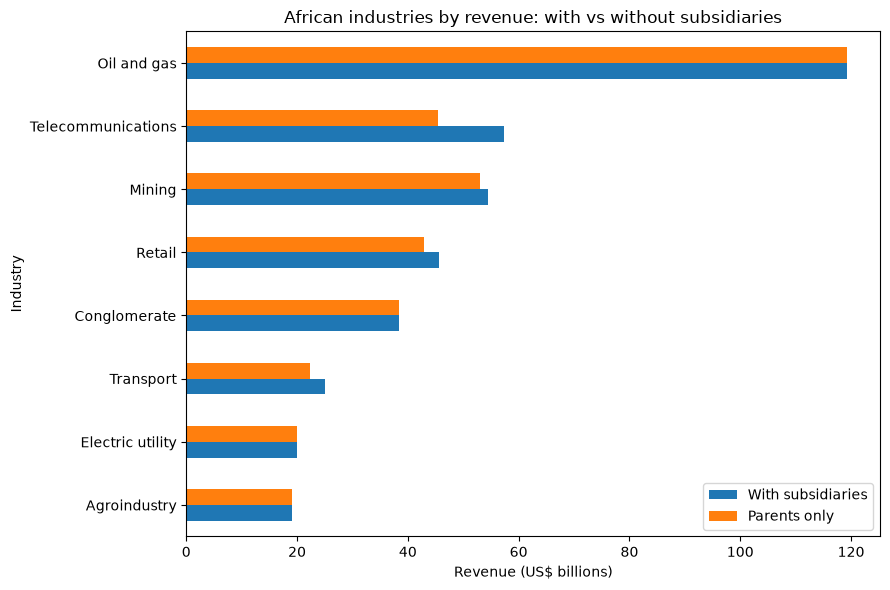

In [8]:


plot_df = compare.nlargest(8, "with_subsidiaries")[["with_subsidiaries", "parents_only"]]
plot_df = plot_df.sort_values("with_subsidiaries")        # biggest ends up at the top

plot_df.plot.barh(figsize=(9, 6))
plt.title("African industries by revenue: with vs without subsidiaries")
plt.xlabel("Revenue (US$ billions)")
plt.legend(["With subsidiaries", "Parents only"])
plt.tight_layout()
plt.savefig("africa_industry_comparison.png", dpi=150)
plt.show()

The largest industry by revenue is oil and gas, with 119.3 billion US dollars across
12 companies. About 65% of that (77.0 billion) comes from one company, Sonatrach, so
the industry's lead reflects one very large company more than many large ones.

Some companies in the list are subsidiaries of other companies in the same list, so
adding every row counts the same revenue twice. For example, Massmart Wholesale
(3.246) and Massmart Retail (2.654) add up to almost exactly Massmart (5.920). My rule
was: if a company's revenue is already included in a larger listed company, I remove
the smaller entry. This removed MTN Nigeria, MTN South Africa, Vodacom South Africa,
Massmart Wholesale, Massmart Retail, Transnet Freight Rail, Dangote Cement Nigeria and
Gold Fields Ghana. I identified these by name and by checking whether the numbers
added up, so I may have missed some.

Removing them did not change the top result: oil and gas stays first at 119.3 billion
either way. It did change second place. With subsidiaries, telecommunications is
second (57.3) and mining third (54.5). Without them, mining is second (53.0) and
telecommunications third (45.5), because the three telecom subsidiaries account for
11.9 billion. So "telecommunications is second" depends on counting subsidiaries
separately, and I would not rely on it.

Third place is also close. Telecommunications (45.5) and retail (42.9) are within
about 3 billion of each other, and I am unsure whether Maroc Telecom and Groupe Maroc
Telecom are the same business. If one is a duplicate, telecommunications could stay
just ahead of retail or fall behind it, depending on which entry is removed.

One row looks wrong in the source: Ethiopian Airlines is ranked 44th but has a
revenue of 6.118 billion, which does not fit that position. I left it in, because
transport is not near the top of the ranking either way.

In [12]:
# This portion was just to experiment with Maroc Telecom and Groupe Maroc Telecom to see how each of them affect results.
no_maroc = parents_only[parents_only["Company"] != "Maroc Telecom"]
print(no_maroc.groupby("Industry")["Revenue_bn"].sum().nlargest(5).round(1))

no_groupe = parents_only[parents_only["Company"] != "Groupe Maroc Telecom"]
print(no_groupe.groupby("Industry")["Revenue_bn"].sum().nlargest(5).round(1))

Industry
Oil and gas           119.3
Mining                 53.0
Telecommunications     43.2
Retail                 42.9
Conglomerate           38.4
Name: Revenue_bn, dtype: float64
Industry
Oil and gas           119.3
Mining                 53.0
Retail                 42.9
Telecommunications     41.4
Conglomerate           38.4
Name: Revenue_bn, dtype: float64


In [11]:
africa.to_csv('africa_companies_by_revenue.csv', index=False)